# Technical Validation - RELAX Dataset

This notebook implements the technical validation procedures for the **RELAX** longitudinal stress dataset, as described in:

>Halmich, C., Jung, O., Schmoigl-Tonis, M., Schranz, C., Kremser, W., Kunas, B., & Laireiter, A.-R. (2026).
> *A six-week longitudinal dataset of wearable and self-reported stress measurements in working adults*
> Sci Data (2026).

The dataset is published on Zenodo: 
>Halmich, C., Jung, O., Schmoigl-Tonis, M., Schranz, C., Kremser, W., Kunas, B., & Laireiter, A.-R. (2026).
> *A six-week longitudinal dataset of wearable and self-reported stress measurements in working adults*
> [Data set]. Salzburg Research Forschungsgesellschaft mbH.
> https://doi.org/10.5281/zenodo.18693288

---
## Dataset overview
The dataset was collected from **31 participants** over a **six-week longitudinal field study** in naturalistic occupational settings. It combines:

- **Wearable physiological data** recorded with a Polar Verity Sense sensor (upper arm):
  - Accelerometer (ACC) signals - triaxial, sampled at ~52 Hz
  - Interbeat intervals (IBI) - event-based pulse-to-pulse intervals (PPIs)
- **Self-reported stress assessments** collected via the RelaxApp mobile application:
  - Morning questionnaire (MFB), evening questionnaire (AFB), and interval questionnaire (IFB)

Wearable data are provided per participant as Apache Parquet files (`acc_data.parquet`, `ibi_data.parquet`). Questionnaire responses are provided in spreadsheet format.

---
## Validation procedures

This notebook covers the following validation steps, as reported in the Technical Validation section of the Data Descriptor:

1. **Structural integrity** — verify expected files, column names, and data types
2. **Timestamp integrity** — check for strictly increasing timestamps, duplicates, and phase boundary compliance
3. **ACC sampling rate** — confirm stable ~52 Hz acquisition
4. **IBI plausibility** — apply physiological range filter (300–2000 ms) and inspect error estimates and blocker flags
5. **Data completeness** — compute daily and weekly coverage per participant for ACC and IBI modalities

---

## License
This notebook is released under the [MIT License](https://opensource.org/licenses/MIT).
The accompanying dataset is released under the
[Creative Commons Attribution 4.0 International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).

© 2026 Halmich, Jung, Schmoigl-Tonis, Schranz, Kremser, Kunas & Laireiter.
Salzburg Research Forschungsgesellschaft mbH.

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import openpyxl
import fastparquet

# =============================================================================
# Dataset path
# -----------------------------------------------------------------------------
# Download the dataset from Zenodo (https://doi.org/10.5281/zenodo.18693288),
# unzip the archive, and set DATA_PATH to the extracted `data/` directory.
# Expected structure:
#   RELAXDataset/
#   └── data/
#       ├── <participant_id>/
#       │   ├── acc_data.parquet
#       │   └── ibi_data.parquet
#       └── ...
# =============================================================================

DATA_PATH = Path("RELAXDataset/data/")

## Participant Demographics

Summary statistics for the 31 enrolled participants, derived from self-reported metadata collected at enrolment. Gender is encoded as `m` (male) and `w` (female). Age is computed from birth year relative to the study start (2024). BMI is derived from self-reported height (cm) and weight (kg) as weight / (height / 100)².

### Educational Background

Highest completed educational level, self-reported at enrolment. Numeric codes (0–7) are
mapped to descriptive labels for readability

### Occupational Sector

Industry sector of employment, self-reported at enrolment. Numeric codes (0–12) are
mapped to sector labels.


In [53]:
participant_info = pd.read_excel("RELAXDataset/questionnaire_responses.xlsx", sheet_name='users')
participant_info = participant_info.drop(columns=["id", "username", "device_vs"])

# Gender distribution w = female and m = male
print(participant_info["metadata_json/gender"].value_counts(normalize=True) * 100)
print("----------------------------------------------\n Age distribution:")
# Age distribution
participant_info["age"] = 2024 - participant_info["metadata_json/age"]
print(participant_info["age"].describe())
print("----------------------------------------------\n BMI distribution:")
# BMI distribution
participant_info["bmi"] = (
    participant_info["metadata_json/weight"]
    / (participant_info["metadata_json/height"] / 100) ** 2
)
print(participant_info["bmi"].describe())

metadata_json/gender
w    64.516129
m    35.483871
Name: proportion, dtype: float64
----------------------------------------------
 Age distribution:
count    31.000000
mean     40.322581
std       9.339476
min      25.000000
25%      34.000000
50%      41.000000
75%      45.500000
max      63.000000
Name: age, dtype: float64
----------------------------------------------
 BMI distribution:
count    31.000000
mean     25.149405
std       4.646330
min      19.605192
25%      21.794391
50%      23.931624
75%      26.454406
max      39.682540
Name: bmi, dtype: float64


In [76]:
EDU_LABELS = {
    0: "None",
    1: "Compulsory school",
    2: "Apprenticeship/technical school",
    3: "Abitur/Fachabitur/Matura",
    4: "Master's examination",
    5: "Graduate university degree/Bachelor",
    6: "Postgraduate university degree/Master's",
    7: "Higher (from doctorate)",
}

educational_info = pd.read_excel("RELAXDataset/questionnaire_responses.xlsx", sheet_name='profile1')


educational_info["education_label"] = educational_info["answers/profile1-7-1"].map(EDU_LABELS)
educational_info["education_label"].value_counts()


education_label
Postgraduate university degree/Master's    12
Graduate university degree/Bachelor         8
Apprenticeship/technical school             7
Abitur/Fachabitur/Matura                    7
Compulsory school                           2
Higher (from doctorate)                     2
Master's examination                        1
Name: count, dtype: int64

In [6]:
SECTOR_LABELS = {
    0: "Industry",
    1: "Agriculture",
    2: "Services",
    3: "Construction",
    4: "Chemistry, metal and raw materials",
    5: "Trade",
    6: "Finance, insurance and real estate",
    7: "Tourism, gastronomy and leisure",
    8: "Media",
    9: "Health",
    10: "Society, Sport and Culture",
    11: "Energy and Environment",
    12: "Politics",
}

# Multiple answers possible
occupation_info = pd.read_excel("RELAXDataset/questionnaire_responses.xlsx", sheet_name='profile2')

occupation_info["occupation_label"] = occupation_info["answers/profile2-1-1"].map(SECTOR_LABELS)

occupation_info.drop_duplicates(subset=["user", "answers/profile2-1-1"])["occupation_label"].value_counts()


occupation_label
Services                              10
Society, Sport and Culture             5
Trade                                  4
Energy and Environment                 3
Finance, insurance and real estate     2
Health                                 2
Industry                               2
Media                                  1
Chemistry, metal and raw materials     1
Tourism, gastronomy and leisure        1
Politics                               1
Name: count, dtype: int64

In [4]:
occupation_info

,user,manual_date,readable_date,answers/profile2-1-1,answers/profile2-2-1,answers/profile2-3-1/0,answers/profile2-3-1/1,answers/profile2-3-1/2,answers/profile2-3-1/3,answers/profile2-3-1/4,answers/profile2-4-1/0,answers/profile2-4-1/1,answers/profile2-4-1/2,answers/profile2-4-1/3,answers/profile2-5-1,answers/profile2-6-1,occupation_label
0,12,1708978861755,2024-02-26 20:21:01.755,2.0,4,0,1.0,2.0,4.0,NaN,1.0,NaN,NaN,NaN,5,4,Services
1,13,1708921628235,2024-02-26 04:27:08.235,10.0,4,0,1.0,2.0,3.0,4.0,NaN,NaN,NaN,NaN,3,4,"Society, Sport and Culture"
2,14,1708930377787,2024-02-26 06:52:57.787,8.0,4,1,2.0,4.0,NaN,NaN,1.0,NaN,NaN,NaN,5,5,Media
3,14,1712648595144,2024-04-09 07:43:15.144,10.0,3,4,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,5,5,"Society, Sport and Culture"
4,15,1708933169827,2024-02-26 07:39:29.827,5.0,5,1,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5,4,Trade
5,15,1713887258945,2024-04-23 15:47:38.945,5.0,5,1,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5,5,Trade
6,16,1708944956209,2024-02-26 10:55:56.209,5.0,3,0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,5,4,Trade
7,17,1708928209129,2024-02-26 06:16:49.129,2.0,5,1,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,5,4,Services
8,17,1712604528458,2024-04-08 19:28:48.458,5.0,4,1,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,5,4,Trade
9,18,1708932403048,2024-02-26 07:26:43.048,11.0,3,0,1.0,2.0,3.0,4.0,1.0,5.0,NaN,NaN,5,5,Energy and Environment


## Data Type and Sampling Frequency Validation

We verify that the accelerometer (`acc_data.parquet`) and IBI (`ibi_data.parquet`) files share a consistent schema across all participants, and that the accelerometer sampling frequency matches the nominal 52 Hz.

In [3]:
participant_dirs = sorted(p for p in DATA_PATH.iterdir() if p.is_dir() and not p.name.startswith("."))

rows = []
for p_dir in participant_dirs:
    acc = pd.read_parquet(p_dir / "acc_data.parquet")
    ibi = pd.read_parquet(p_dir / "ibi_data.parquet")
    fs = 1 / acc["timestamp"].diff().dt.total_seconds().median()
    rows.append({
        "participant_id": p_dir.name,
        "fs_hz": round(fs, 3),
        **{f"acc_{col}": str(dt) for col, dt in acc.dtypes.items()},
        **{f"ibi_{col}": str(dt) for col, dt in ibi.dtypes.items()},
    })

results = pd.DataFrame(rows).set_index("participant_id")

dtype_cols = [c for c in results.columns if c != "fs_hz"]
print("Dtypes consistent across all participants:", results[dtype_cols].nunique().eq(1).all())
print("Sampling frequency consistent:", results["fs_hz"].nunique() == 1)
results[["fs_hz"]]


Dtypes consistent across all participants: True
Sampling frequency consistent: True


,fs_hz
participant_id,
12,52.0
13,52.0
14,52.0
15,52.0
16,52.0
17,52.0
18,52.0
21,52.0
22,52.0


## Data Coverage Computation

Daily data coverage is computed for both the accelerometer (ACC) and IBI signals using a time-based method: consecutive timestamp differences ≤ 5 s are summed per calendar day and divided by 86,400 s. Gaps exceeding 5 s are treated as missing. Results are saved to `acc_coverage_per_day.csv` and `ibi_coverage_per_day.csv`.


In [ ]:
ACC_FILENAME = "acc_data.parquet"
IBI_FILENAME = "ibi_data.parquet"

THRESHOLD_SEC = 5.0
DAY_SECONDS = 24 * 60 * 60
FS_NOMINAL_HZ = 52.0
EXPECTED_PER_DAY = int(FS_NOMINAL_HZ * DAY_SECONDS)

# ---- HELPERS ----
def sampling_frequency_hz(df: pd.DataFrame, ts_col: str = "timestamp") -> float:
    ts = pd.to_datetime(df[ts_col], utc=True, errors="coerce").dropna().sort_values()
    if len(ts) < 2:
        return float("nan")
    dt = ts.diff().dt.total_seconds().dropna()
    med = float(dt.median()) if len(dt) else float("nan")
    return (1.0 / med) if (med and med > 0) else float("nan")


def coverage_per_day_timebased(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """
    R-equivalent time-based coverage:
    - dt = diff(timestamp)
    - valid_dt = 0 if NA or dt > THRESHOLD_SEC else dt
    - coverage_percent = 100 * sum(valid_dt) / 86400
    """
    x = df.copy()
    x[ts_col] = pd.to_datetime(x[ts_col], utc=True, errors="coerce")
    x = x.dropna(subset=[ts_col]).sort_values(ts_col)

    x["day"] = x[ts_col].dt.floor("D")
    dt_sec = x[ts_col].diff().dt.total_seconds()

    x["valid_dt"] = np.where(dt_sec.isna() | (dt_sec > THRESHOLD_SEC), 0.0, dt_sec.astype(float))

    out = (
        x.groupby("day", as_index=False)
         .agg(
             covered_minutes=("valid_dt", lambda v: float(np.nansum(v)) / 60.0),
             covered_seconds=("valid_dt", lambda v: float(np.nansum(v))),
             coverage_percent=("valid_dt", lambda v: 100.0 * float(np.nansum(v)) / DAY_SECONDS),
             n_samples=(ts_col, "size"),
             first_ts=(ts_col, "min"),
             last_ts=(ts_col, "max"),
         )
    )
    return out


def coverage_per_day_countbased(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """
    Optional (your earlier Python logic): rows / expected_rows_per_day.
    Not equivalent to the R method, but sometimes useful as an additional diagnostic.
    """
    x = df.copy()
    x[ts_col] = pd.to_datetime(x[ts_col], utc=True, errors="coerce")
    x = x.dropna(subset=[ts_col])
    x["day"] = x[ts_col].dt.date

    daily_counts = x.groupby("day").size().rename("n_samples").reset_index()
    daily_counts["coverage_ratio"] = daily_counts["n_samples"] / EXPECTED_PER_DAY
    daily_counts["coverage_percent_countbased"] = 100.0 * daily_counts["coverage_ratio"]
    return daily_counts


# ---- RUN FOR ALL PARTICIPANTS ----
acc_rows = []
ibi_rows = []
participant_dirs = sorted([p for p in DATA_PATH.iterdir() if p.is_dir() and not p.name.startswith(".")])

for p_dir in participant_dirs:
    p_id = p_dir.name

    acc_path = p_dir / ACC_FILENAME
    if acc_path.exists():
        acc = pd.read_parquet(acc_path)
        acc_cov = coverage_per_day_timebased(acc, "timestamp")
        acc_cov["participant_id"] = p_id
        acc_cov["fs_hz_median"] = sampling_frequency_hz(acc, "timestamp")
        acc_cov_count = coverage_per_day_countbased(acc, "timestamp")
        acc_cov_count["day"] = pd.to_datetime(acc_cov_count["day"]).dt.tz_localize("UTC")
        acc_cov = acc_cov.merge(
            acc_cov_count[["day", "coverage_percent_countbased"]], on="day", how="left"
        )
        acc_rows.append(acc_cov)
    else:
        print(f"[SKIP] {p_id}: missing {ACC_FILENAME}")

    ibi_path = p_dir / IBI_FILENAME
    if ibi_path.exists():
        ibi = pd.read_parquet(ibi_path)
        ibi_cov = coverage_per_day_timebased(ibi, "timestamp")
        ibi_cov["participant_id"] = p_id
        ibi_cov_count = coverage_per_day_countbased(ibi, "timestamp")
        ibi_cov_count["day"] = pd.to_datetime(ibi_cov_count["day"]).dt.tz_localize("UTC")
        ibi_cov = ibi_cov.merge(
            ibi_cov_count[["day", "coverage_percent_countbased"]], on="day", how="left"
        )
        ibi_rows.append(ibi_cov)
    else:
        print(f"[SKIP] {p_id}: missing {IBI_FILENAME}")

acc_coverage = pd.concat(acc_rows, ignore_index=True) if acc_rows else pd.DataFrame()
ibi_coverage = pd.concat(ibi_rows, ignore_index=True) if ibi_rows else pd.DataFrame()

acc_coverage.to_csv("acc_coverage_per_day.csv", index=False)
ibi_coverage.to_csv("ibi_coverage_per_day.csv", index=False)

print(f"ACC: {len(acc_rows)} participants, {len(acc_coverage)} day-rows")
print(f"IBI: {len(ibi_rows)} participants, {len(ibi_coverage)} day-rows")

ACC: 31 participants, 1149 day-rows
IBI: 31 participants, 1157 day-rows


## ACC Coverage 
### ACC Coverage — Per-Participant Analysis

Per-participant summary of daily accelerometer coverage, including median, interquartile
range, and the proportion of days above 80 % and below 20 % coverage.

Two visualisations are produced:
- **Heatmap** — Heatmap of daily accelerometer data coverage (%) per participant across the six-week study period. Rows represent participants and columns represent calendar days; color intensity indicates the proportion of recorded data per day (0–100%). White cells denote days without available accelerometer data. 
- **Boxplot** — Distribution of daily wearable data coverage (%) per participant across the six-week study period. Boxplots represent the median (central line), interquartile range (box), and range excluding outliers (whiskers); points indicate outlier days.


In [4]:
coverage_all = pd.read_csv("acc_coverage_per_day.csv", parse_dates=["day", "first_ts", "last_ts"])

summary = (
    coverage_all
    .groupby("participant_id")
    .agg(
        n_days=("day", "count"),
        median_cov=("coverage_percent", "median"),
        q1_cov=("coverage_percent", lambda x: x.quantile(0.25)),
        q3_cov=("coverage_percent", lambda x: x.quantile(0.75)),
        pct_days_above_80=("coverage_percent", lambda x: (x > 80).mean() * 100),
        pct_days_below_20=("coverage_percent", lambda x: (x < 20).mean() * 100),
    )
)
print(summary.to_string(float_format="%.2f"))

                n_days  median_cov  q1_cov  q3_cov  pct_days_above_80  pct_days_below_20
participant_id                                                                          
12                  40       45.17   32.77   64.89               0.00              10.00
13                  39       44.00   33.64   51.34               0.00              15.38
14                  31       30.36   14.97   50.04               0.00              29.03
15                  43       34.19   19.96   40.84               0.00              25.58
16                  42       36.07   22.99   49.80               0.00              19.05
17                  42       72.73   61.85   81.64              30.95               4.76
18                  42       55.12   40.44   68.01               4.76               2.38
21                  40       44.14   28.11   55.26               2.50               7.50
22                  42       41.16   28.16   52.73               0.00              14.29
23                  4

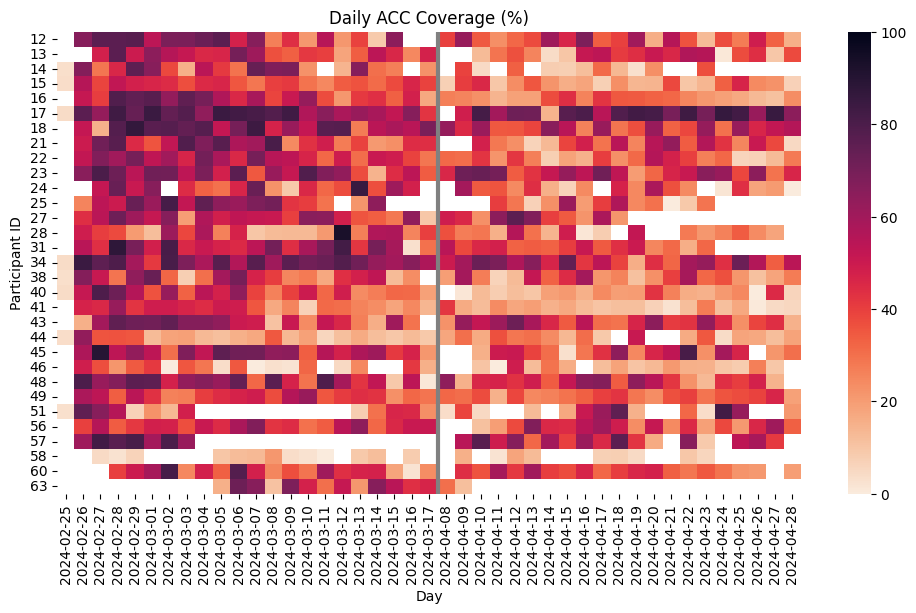

In [ ]:
pivot = coverage_all.pivot(
    index="participant_id",
    columns="day",
    values="coverage_percent"
)

pivot.columns = pd.to_datetime(pivot.columns).strftime("%Y-%m-%d")
col_dates = pivot.columns
pause_date = pd.to_datetime('2024-04-08').strftime("%Y-%m-%d")
pause_idx = list(col_dates).index(pause_date)


plt.figure(figsize=(12,6))
ax = sns.heatmap(pivot, vmin=0, vmax=100, cmap="rocket_r")
ax.axvline(pause_idx, color="grey", linewidth=3)

plt.xlabel("Day")
plt.ylabel("Participant ID")
plt.title("Daily ACC Coverage (%)")
plt.savefig("Daily_Acc_Heatmap_New.png", bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

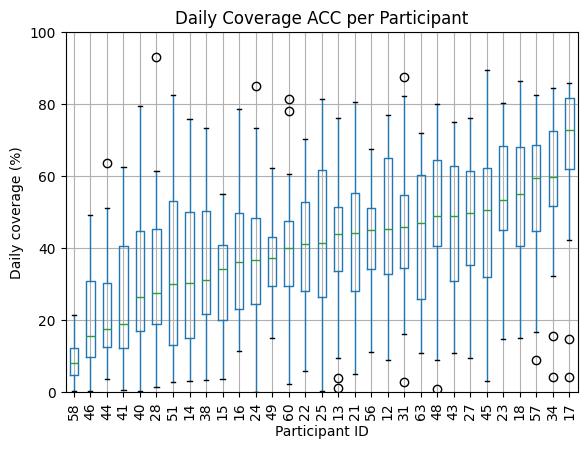

In [6]:
median_order = (
    coverage_all.groupby("participant_id")["coverage_percent"]
    .median()
    .sort_values(ascending=True)
    .index
)

coverage_all["participant_id"] = pd.Categorical(
    coverage_all["participant_id"],
    categories=median_order,
    ordered=True,
)

plt.figure(figsize=(12,6))
coverage_all.boxplot(column="coverage_percent", by="participant_id", rot=90)
plt.ylim(0, 100)
plt.ylabel("Daily coverage (%)")
plt.xlabel("Participant ID")
plt.title("Daily Coverage ACC per Participant")
plt.suptitle("")
#plt.show()
plt.savefig("Daily_Acc_new.png", bbox_inches="tight")

### ACC Coverage — Weekly Summary Table

Weekly data availability aggregated across all participants, excluding the three-week
break between phases (2024-03-18 to 2024-04-07). Study days are compressed into a
continuous 1–42 index so that weeks 1–3 correspond to phase 1 and weeks 4–6 to phase 2.

For each week, the proportion of available data is computed as total covered seconds /
(7 × 86,400 s), and mean daily hours are derived from per-participant daily covered
seconds. Values are reported as mean ± SD across participants.


In [ ]:
DAY_SECONDS = 24 * 60 * 60
df = coverage_all.copy()
df["day"] = pd.to_datetime(df["day"], utc=True).dt.floor("D")

study_start  = pd.Timestamp("2024-02-26", tz="UTC") 
break_start  = pd.Timestamp("2024-03-18", tz="UTC")
phase2_start = pd.Timestamp("2024-04-08", tz="UTC")  

break_days = (phase2_start - break_start).days  # 21


# keep only active measurement periods (phase 1 + phase 2)
df = df[(df["day"] >= study_start) & (df["day"] < break_start) |
        (df["day"] >= phase2_start)]

# effective day index: compress the break out
df["study_day_idx"] = (df["day"] - study_start).dt.days + 1
df.loc[df["day"] >= phase2_start, "study_day_idx"] -= break_days

df["week"] = ((df["study_day_idx"] - 1) // 7) + 1

df = df[df["week"].between(1, 6)]

pw = (
    df.groupby(["participant_id", "week"], as_index=False)
      .agg(
          weekly_covered_seconds=("covered_seconds", "sum"),
          mean_daily_covered_seconds=("covered_seconds", "mean"),
      )
)

pw["prop_available"] = pw["weekly_covered_seconds"] / (7 * DAY_SECONDS)
pw["daily_hours"] = pw["mean_daily_covered_seconds"] / 3600

week_table = (
    pw.groupby("week")
      .agg(
          prop_mean=("prop_available", "mean"),
          prop_std=("prop_available", "std"),
          hours_mean=("daily_hours", "mean"),
          hours_std=("daily_hours", "std"),
      )
      .reset_index()
)

total = pd.DataFrame([{
    "week": "Total",
    "prop_mean": pw["prop_available"].mean(),
    "prop_std": pw["prop_available"].std(),
    "hours_mean": pw["daily_hours"].mean(),
    "hours_std": pw["daily_hours"].std(),
}])

week_table = pd.concat([week_table, total], ignore_index=True)

out = week_table.copy()
out["Week number"] = out["week"].apply(lambda w: f"Week {int(w)}" if str(w).isdigit() else "Total")
out["Proportion of available data (mean ± std)"] = (
    out["prop_mean"].map(lambda v: f"{v:.4f}") + " ± " + out["prop_std"].map(lambda v: f"{v:.4f}")
)
out["Daily data (hours) (mean ± std)"] = (
    out["hours_mean"].map(lambda v: f"{v:.2f}") + " ± " + out["hours_std"].map(lambda v: f"{v:.2f}")
)

out = out[["Week number", "Proportion of available data (mean ± std)", "Daily data (hours) (mean ± std)"]]
out

1 42
1 6


,Week number,Proportion of available data (mean ± std),Daily data (hours) (mean ± std)
0,Week 1,0.5205 ± 0.1567,12.83 ± 3.59
1,Week 2,0.4677 ± 0.1558,11.29 ± 3.70
2,Week 3,0.3585 ± 0.1450,9.25 ± 3.05
3,Week 4,0.3017 ± 0.1589,8.14 ± 3.46
4,Week 5,0.3336 ± 0.1527,8.56 ± 3.36
5,Week 6,0.2756 ± 0.1665,7.56 ± 3.59
6,Total,0.3759 ± 0.1775,9.60 ± 3.89


In [9]:
acc_values = coverage_all["coverage_percent"]

acc_median = acc_values.median()
acc_q1 = acc_values.quantile(0.25)
acc_q3 = acc_values.quantile(0.75)

acc_median, acc_q1, acc_q3

(np.float64(41.33054004651853),
 np.float64(24.18273980266667),
 np.float64(56.677229157185195))

## IBI Coverage 
### IBI Coverage — Per-Participant Analysis

Per-participant summary of daily IBI coverage, including median, interquartile
range, and the proportion of days above 80 % and below 20 % coverage.

Two visualisations are produced:
- **Heatmap** — Heatmap of daily IBI data coverage (%) per participant across the six-week study period. Rows represent participants and columns represent calendar days; color intensity indicates the proportion of recorded data per day (0–100%). White cells denote days without available IBI data. 
- **Boxplot** — Distribution of daily wearable data coverage (%) per participant across the six-week study period. Boxplots represent the median (central line), interquartile range (box), and range excluding outliers (whiskers); points indicate outlier days.


In [10]:
coverage_all = pd.read_csv("ibi_coverage_per_day.csv", parse_dates=["day", "first_ts", "last_ts"])

In [11]:
summary = (
    coverage_all
    .groupby("participant_id")
    .agg(
        n_days=("day", "count"),
        median_cov=("coverage_percent", "median"),
        q1_cov=("coverage_percent", lambda x: x.quantile(0.25)),
        q3_cov=("coverage_percent", lambda x: x.quantile(0.75)),
        pct_days_above_80=("coverage_percent", lambda x: (x > 80).mean() * 100),
        pct_days_below_20=("coverage_percent", lambda x: (x < 20).mean() * 100),
    )
)
#summary.to_string(float_format="%.2f")
print(summary.to_string(float_format="%.2f"))

                n_days  median_cov  q1_cov  q3_cov  pct_days_above_80  pct_days_below_20
participant_id                                                                          
12                  40       42.93   28.41   61.93               0.00              10.00
13                  39       44.05   31.39   49.02               0.00              15.38
14                  31       28.92   14.85   47.05               0.00              29.03
15                  43       32.95   19.77   38.13               0.00              25.58
16                  42       33.36   21.51   47.49               0.00              19.05
17                  43       73.25   58.03   80.29              27.91               6.98
18                  42       55.55   43.04   68.02               7.14               2.38
21                  42       44.35   28.37   58.55               4.76               9.52
22                  42       35.79   26.09   49.76               0.00              16.67
23                  4

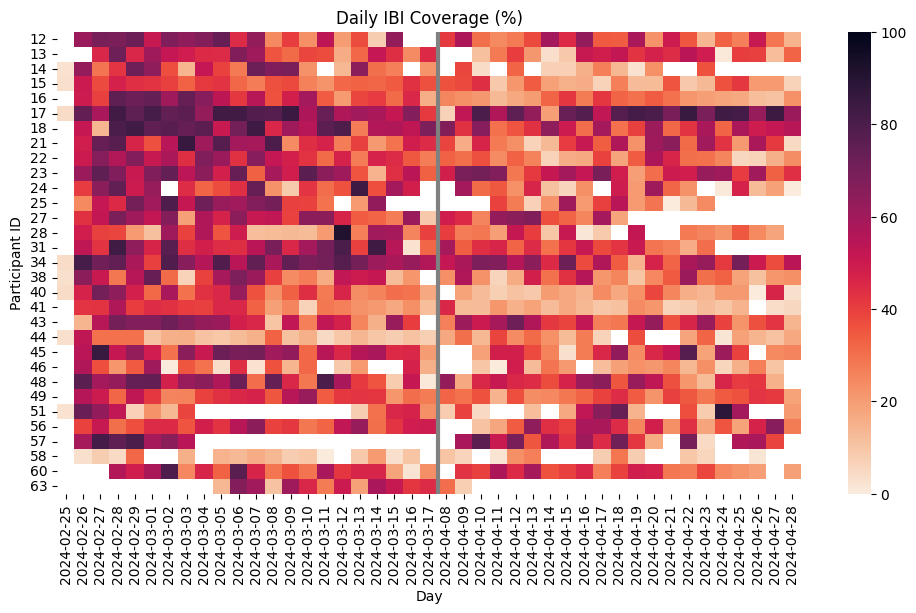

In [13]:
pivot = coverage_all.pivot(
    index="participant_id",
    columns="day",
    values="coverage_percent"
)

# Convert datetime columns to readable date format
pivot.columns = pd.to_datetime(pivot.columns).strftime("%Y-%m-%d")
col_dates = pivot.columns
# Find index of pause date
pause_date = pd.to_datetime('2024-04-08').strftime("%Y-%m-%d")
pause_idx = list(col_dates).index(pause_date)

plt.figure(figsize=(12,6))
ax = sns.heatmap(pivot, vmin=0, vmax=100, cmap="rocket_r")
# Add vertical line
ax.axvline(pause_idx, color="grey", linewidth=3)
plt.xlabel("Day")
plt.ylabel("Participant ID")
plt.title("Daily IBI Coverage (%)")
plt.savefig("Daily_IBI_Heatmap_New.png", bbox_inches="tight")
#plt.show()

<Figure size 1200x600 with 0 Axes>

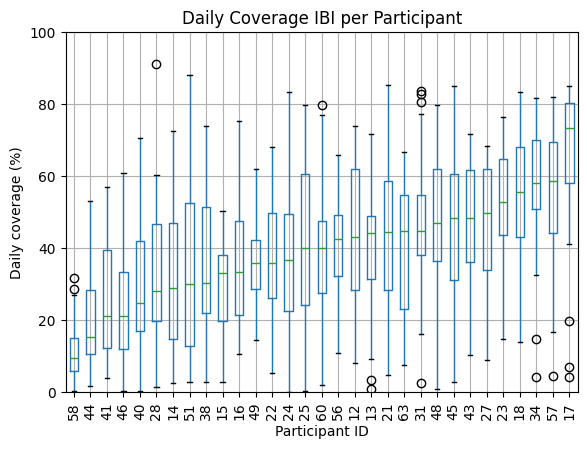

In [14]:
median_order = (
    coverage_all.groupby("participant_id")["coverage_percent"]
    .median()
    .sort_values(ascending=True)
    .index
)

coverage_all["participant_id"] = pd.Categorical(
    coverage_all["participant_id"],
    categories=median_order,
    ordered=True,
)

plt.figure(figsize=(12,6))
coverage_all.boxplot(column="coverage_percent", by="participant_id", rot=90)
plt.ylim(0, 100)
plt.ylabel("Daily coverage (%)")
plt.xlabel("Participant ID")
plt.title("Daily Coverage IBI per Participant")
plt.suptitle("")
#plt.show()
plt.savefig("Daily_IBI_new.png", bbox_inches="tight")

### IBI Coverage — Weekly Summary Table

Weekly data availability aggregated across all participants, excluding the three-week
break between phases (2024-03-18 to 2024-04-07). Study days are compressed into a
continuous 1–42 index so that weeks 1–3 correspond to phase 1 and weeks 4–6 to phase 2.

For each week, the proportion of available data is computed as total covered seconds /
(7 × 86,400 s), and mean daily hours are derived from per-participant daily covered
seconds. Values are reported as mean ± SD across participants.


In [ ]:
#DAY_SECONDS = 86400

df = coverage_all.copy()
df["day"] = pd.to_datetime(df["day"], utc=True).dt.floor("D")

study_start  = pd.Timestamp("2024-02-26", tz="UTC")  # first full day after 23:00 start
break_start  = pd.Timestamp("2024-03-18", tz="UTC")
phase2_start = pd.Timestamp("2024-04-08", tz="UTC")  # first full day after 23:00 start

break_days = (phase2_start - break_start).days  # 21


# keep only active measurement periods (phase 1 + phase 2)
df = df[(df["day"] >= study_start) & (df["day"] < break_start) |
        (df["day"] >= phase2_start)]

# effective day index: compress the break out
df["study_day_idx"] = (df["day"] - study_start).dt.days + 1
df.loc[df["day"] >= phase2_start, "study_day_idx"] -= break_days

df["week"] = ((df["study_day_idx"] - 1) // 7) + 1

df = df[df["week"].between(1, 6)]

pw = (
    df.groupby(["participant_id", "week"], as_index=False)
      .agg(
          weekly_covered_seconds=("covered_seconds", "sum"),
          mean_daily_covered_seconds=("covered_seconds", "mean"),
      )
)

pw["prop_available"] = pw["weekly_covered_seconds"] / (7 * DAY_SECONDS)
pw["daily_hours"] = pw["mean_daily_covered_seconds"] / 3600

week_table = (
    pw.groupby("week")
      .agg(
          prop_mean=("prop_available", "mean"),
          prop_std=("prop_available", "std"),
          hours_mean=("daily_hours", "mean"),
          hours_std=("daily_hours", "std"),
      )
      .reset_index()
)

total = pd.DataFrame([{
    "week": "Total",
    "prop_mean": pw["prop_available"].mean(),
    "prop_std": pw["prop_available"].std(),
    "hours_mean": pw["daily_hours"].mean(),
    "hours_std": pw["daily_hours"].std(),
}])

week_table = pd.concat([week_table, total], ignore_index=True)

# Format like the paper table
out = week_table.copy()
out["Week number"] = out["week"].apply(lambda w: f"Week {int(w)}" if str(w).isdigit() else "Total")
out["Proportion of available data (mean ± std)"] = (
    out["prop_mean"].map(lambda v: f"{v:.4f}") + " ± " + out["prop_std"].map(lambda v: f"{v:.4f}")
)
out["Daily data (hours) (mean ± std)"] = (
    out["hours_mean"].map(lambda v: f"{v:.2f}") + " ± " + out["hours_std"].map(lambda v: f"{v:.2f}")
)

out = out[["Week number", "Proportion of available data (mean ± std)", "Daily data (hours) (mean ± std)"]]
out

1 42
1 6


,Week number,Proportion of available data (mean ± std),Daily data (hours) (mean ± std)
0,Week 1,0.5054 ± 0.1427,12.41 ± 3.29
1,Week 2,0.4582 ± 0.1472,11.06 ± 3.47
2,Week 3,0.3507 ± 0.1428,9.06 ± 3.04
3,Week 4,0.3016 ± 0.1544,7.99 ± 3.31
4,Week 5,0.3314 ± 0.1446,8.54 ± 3.09
5,Week 6,0.2681 ± 0.1654,7.37 ± 3.63
6,Total,0.3689 ± 0.1702,9.40 ± 3.71


In [16]:
ibi_values = coverage_all["coverage_percent"]

ibi_median = ibi_values.median()
ibi_q1 = ibi_values.quantile(0.25)
ibi_q3 = ibi_values.quantile(0.75)

ibi_median, ibi_q1, ibi_q3

(np.float64(39.99087964118518),
 np.float64(23.24304858844444),
 np.float64(56.38156831703704))

### IBI Plausibility

Inter-beat interval (IBI) data are validated against three criteria:

- **Physiological range** — PPI values outside 300–2000 ms are flagged as
  implausible (< 30 bpm or > 200 bpm).
- **Error estimate** — the sensor-reported `ibi_errorEstimate` field (ms) is
  summarised as median, IQR, and 95th percentile across all participants.
- **Blocker flag** — the proportion of intervals marked as blocked
  (`ibi_blocker = True`) by the sensor's motion-artefact detector is reported.
- **Timestamp consistency** — the difference between consecutive timestamp
  intervals and the recorded PPI value is computed; values near 0 ms confirm
  that event timestamps are consistent with the reported intervals.


In [ ]:

all_fs = []
all_ppi_values = []
all_error_estimates = []
all_blocker_values = []

for P_ID in os.listdir(DATA_PATH):
    if P_ID.startswith("."):
        continue

    a_ibi = pd.read_parquet(f"{DATA_PATH}/{P_ID}/ibi_data.parquet")

    all_error_estimates.extend(a_ibi["ibi_errorEstimate"].values)

    all_blocker_values.extend(a_ibi["ibi_blocker"].values)

    all_ppi_values.extend(a_ibi["ibi_ppi"].values)
    time_diff = a_ibi["timestamp"].diff().dt.total_seconds() * 1000  # ms
    ibi_values = a_ibi["ibi_ppi"]

    diff = time_diff - ibi_values
    all_fs.extend(diff)


all_error_estimates = np.array(all_error_estimates)
all_blocker_values = np.array(all_blocker_values)
all_ppi_values = np.array(all_ppi_values)

# errorEstimate
err_median = np.median(all_error_estimates)
err_iqr = np.percentile(all_error_estimates, [25, 75])
err_95 = np.percentile(all_error_estimates, 95)

# blocker proportion
blocker_rate = np.mean(all_blocker_values)

low, high = 300, 2000
outside = ((all_ppi_values
 < low) | (all_ppi_values
 > high)).mean()
outside

print("IBI errorEstimate:")
print(f"Median: {err_median:.2f} ms")
print(f"IQR: {err_iqr[0]:.2f} – {err_iqr[1]:.2f} ms")
print(f"95th percentile: {err_95:.2f} ms\n")

print("IBI blocker proportion:")
print(f"{blocker_rate * 100:.2f}% of intervals flagged")

err_median = np.median(all_ppi_values)
err_iqr = np.percentile(all_ppi_values, [25, 75])
err_95 = np.percentile(all_ppi_values, 95)


print("IBI PPI values outside 300-2000 ms:", outside)
print(f"Median: {err_median:.2f} ms")
print(f"IQR: {err_iqr[0]:.2f} – {err_iqr[1]:.2f} ms")
print(f"95th percentile: {err_95:.2f} ms\n")


IBI errorEstimate:
Median: 15.00 ms
IQR: 11.00 – 30.00 ms
95th percentile: 490.00 ms

IBI blocker proportion:
35.95% of intervals flagged
IBI PPI values outside 300-2000 ms: 0.011943668083770752
Median: 846.00 ms
IQR: 726.00 – 986.00 ms
95th percentile: 1379.00 ms

